# # Parte 3: Cruce por ubigeo y análisis
#
# **Grupo 9** · Temporada: **1 de enero al 31 de mayo de 2022**
#
# Unimos los decretos por departamento (Parte 1) con la lluvia por departamento (Parte 2) usando el **ubigeo** del INEI, y respondemos: *¿El Estado declara emergencia donde más llueve?*

In [1]:
import os
import unicodedata

import pandas as pd
import plotly.express as px
from IPython.display import Image, display

pd.set_option("display.width", 200)
os.makedirs("graficos", exist_ok=True)

# ## Paso 1: crear `datos/ubigeos.csv`
#
# Escribimos los 25 ubigeos departamentales del INEI **como texto** (`"01"`, `"02"`, ...).

In [2]:
ubigeos = pd.DataFrame({
    "ubigeo": [f"{i:02d}" for i in range(1, 26)],
    "departamento": ["Amazonas", "Áncash", "Apurímac", "Arequipa", "Ayacucho",
                     "Cajamarca", "Callao", "Cusco", "Huancavelica", "Huánuco",
                     "Ica", "Junín", "La Libertad", "Lambayeque", "Lima",
                     "Loreto", "Madre de Dios", "Moquegua", "Pasco", "Piura",
                     "Puno", "San Martín", "Tacna", "Tumbes", "Ucayali"],
})
ubigeos.to_csv("datos/ubigeos.csv", index=False, encoding="utf-8-sig")
ubigeos.head()

,ubigeo,departamento
0,01,Amazonas
1,02,Áncash
2,03,Apurímac
3,04,Arequipa
4,05,Ayacucho


# ## Paso 2: leer el archivo dos veces

In [3]:
sin_dtype = pd.read_csv("datos/ubigeos.csv")
con_dtype = pd.read_csv("datos/ubigeos.csv", dtype={"ubigeo": str})

comparacion = pd.DataFrame({
    "departamento": con_dtype["departamento"],
    "ubigeo_sin_dtype": sin_dtype["ubigeo"],
    "ubigeo_con_dtype": con_dtype["ubigeo"],
})
print("Tipo sin dtype:", sin_dtype["ubigeo"].dtype)
print("Tipo con dtype:", con_dtype["ubigeo"].dtype)
comparacion.head(10)

Tipo sin dtype: int64
Tipo con dtype: str


,departamento,ubigeo_sin_dtype,ubigeo_con_dtype
0,Amazonas,1,01
1,Áncash,2,02
2,Apurímac,3,03
3,Arequipa,4,04
4,Ayacucho,5,05
5,Cajamarca,6,06
6,Callao,7,07
7,Cusco,8,08
8,Huancavelica,9,09
9,Huánuco,10,10


In [4]:
# Consecuencia práctica: un cruce entre las dos versiones no encuentra ninguna coincidencia
print("¿'01' == 1?", "01" == 1)

# 1) pandas no deja cruzar una columna de texto con una de números
try:
    con_dtype.merge(sin_dtype, on="ubigeo")
except ValueError as e:
    print("Error al cruzar:", e)

# 2) Y si convertimos el número a texto sin cuidado, '1' tampoco es '01'
comun = set(con_dtype["ubigeo"]) & set(sin_dtype["ubigeo"].astype(str))
print(f"Coinciden {len(comun)} de 25 ubigeos; se pierden los 01-09:",
      sorted(set(con_dtype["ubigeo"]) - comun))

¿'01' == 1? False
Error al cruzar: You are trying to merge on str and int64 columns for key 'ubigeo'. If you wish to proceed you should use pd.concat
Coinciden 16 de 25 ubigeos; se pierden los 01-09: ['01', '02', '03', '04', '05', '06', '07', '08', '09']


# **¿Por qué importa?**
#
# - Sin `dtype`, pandas ve que la columna solo tiene dígitos y la convierte en **número entero** (`int64`). Así, `"01"` pasa a ser `1` y se **pierde el cero inicial**.
# - El ubigeo **no es una cantidad, es un código**: no tiene sentido sumarlo ni promediarlo, y su forma exacta importa. Los ubigeos de provincia y distrito se arman pegando códigos (por ejemplo, `150101` = Lima/Lima/Lima). Si el departamento queda como `1` en lugar de `01`, ya no coincide con otras bases del INEI.
# - Al cruzar tablas, el texto `"01"` y el número `1` **no son iguales**. La celda de arriba lo muestra de dos formas. Primero, pandas **da error** al cruzar una columna de texto con una numérica. Segundo, si alguien convierte el número a texto sin cuidado, `1` se vuelve `"1"` y no `"01"`: los departamentos **01 a 09** (Amazonas a Huancavelica) **no encuentran pareja** y se perderían en silencio en el cruce.
# - Por eso siempre leemos el ubigeo con `dtype={"ubigeo": str}`.

# ## Paso 3: agregar el ubigeo a las dos tablas

In [5]:
ubigeos = pd.read_csv("datos/ubigeos.csv", dtype={"ubigeo": str})
decretos = pd.read_csv("datos/decretos_por_departamento.csv")
lluvias = pd.read_csv("datos/lluvias_por_departamento.csv")

decretos_u = decretos.merge(ubigeos, on="departamento", how="left")
lluvias_u = lluvias.merge(ubigeos, on="departamento", how="left")

# ## Paso 4: verificación (departamentos sin ubigeo)

In [6]:
print("Decretos sin ubigeo:", decretos_u.loc[decretos_u["ubigeo"].isna(), "departamento"].tolist())
print("Lluvias sin ubigeo: ", lluvias_u.loc[lluvias_u["ubigeo"].isna(), "departamento"].tolist())

Decretos sin ubigeo: []
Lluvias sin ubigeo:  []


# Los nombres coinciden en las dos tablas. La de decretos usa la misma lista de departamentos de la Parte 1, y la de lluvias usa los nombres de Wikipedia, que vienen con tilde (*Áncash*, *Apurímac*, *Huánuco*, *Junín*, *San Martín*) y con *Callao* ya limpio de la nota `[nota 6]` en la Parte 2.
#
# Igual dejamos programada una **corrección por si acaso**: si un nombre no encuentra su ubigeo, se compara sin tildes ni mayúsculas (así *"Ancash"* encontraría a *"Áncash"*, y *"Provincia Constitucional del Callao"* encontraría a *"Callao"*). Al final comprobamos que no quede ninguno sin ubigeo.

In [7]:
def clave(texto):
    t = unicodedata.normalize("NFKD", str(texto)).encode("ascii", "ignore").decode().lower().strip()
    return t.replace("provincia constitucional del ", "")

mapa = dict(zip(ubigeos["departamento"].apply(clave), ubigeos["ubigeo"]))

for tabla in (decretos_u, lluvias_u):
    faltan = tabla["ubigeo"].isna()
    tabla.loc[faltan, "ubigeo"] = tabla.loc[faltan, "departamento"].apply(clave).map(mapa)

assert decretos_u["ubigeo"].notna().all() and lluvias_u["ubigeo"].notna().all()
print("Todos los departamentos tienen ubigeo en las dos tablas.")

Todos los departamentos tienen ubigeo en las dos tablas.


# ## Paso 5: cruce por `ubigeo` (no por nombre)
#
# Usamos `how="outer"` para no perder ningún departamento que esté en una sola de las dos tablas. Luego ponemos el nombre oficial del INEI desde `ubigeos.csv`.

In [8]:
tabla_final = (lluvias_u.drop(columns="departamento")
               .merge(decretos_u.drop(columns="departamento"), on="ubigeo", how="outer", indicator=True))
print(tabla_final["_merge"].value_counts())

tabla_final = (ubigeos.merge(tabla_final.drop(columns="_merge"), on="ubigeo", how="left")
               .sort_values("ubigeo")
               .reset_index(drop=True))

for col in ["declaratorias", "prorrogas"]:
    tabla_final[col] = tabla_final[col].fillna(0).astype(int)

tabla_final = tabla_final[["ubigeo", "departamento", "capital", "latitud", "longitud",
                           "lluvia_total_mm", "dias_lluvia_fuerte", "declaratorias", "prorrogas"]]
tabla_final

_merge
both          25
left_only      0
right_only     0
Name: count, dtype: int64


,ubigeo,departamento,capital,latitud,longitud,lluvia_total_mm,dias_lluvia_fuerte,declaratorias,prorrogas
0,01,Amazonas,Chachapoyas,-6.23169,-77.86903,436.5,1,1,0
1,02,Áncash,Huaraz,-9.52614,-77.52869,975.3,7,0,0
2,03,Apurímac,Abancay,-13.63426,-72.88380,711.8,2,0,0
3,04,Arequipa,Arequipa,-16.39899,-71.53747,189.9,0,0,0
4,05,Ayacucho,Ayacucho,-13.16380,-74.22345,485.1,0,1,0
5,06,Cajamarca,Cajamarca,-7.16378,-78.50027,773.3,1,0,0
6,07,Callao,Callao,-12.05162,-77.13452,39.2,0,0,0
7,08,Cusco,Cusco,-13.53188,-71.96701,710.7,3,0,0
8,09,Huancavelica,Huancavelica,-12.78691,-74.97298,803.8,1,0,0
9,10,Huánuco,Huánuco,-9.92882,-76.23989,444.8,1,0,0


# ## Paso 6: verificación (25 filas y ceros)

In [9]:
print("Filas:", len(tabla_final))
print("Departamentos con 0 declaratorias:", (tabla_final["declaratorias"] == 0).sum())
print("Valores vacíos:\n", tabla_final.isna().sum())

assert len(tabla_final) == 25
assert tabla_final.isna().sum().sum() == 0

Filas: 25
Departamentos con 0 declaratorias: 22
Valores vacíos:
 ubigeo                0
departamento          0
capital               0
latitud               0
longitud              0
lluvia_total_mm       0
dias_lluvia_fuerte    0
declaratorias         0
prorrogas             0
dtype: int64


# Están los 25 departamentos. Los 22 sin ninguna declaratoria aparecen con **0** y no desaparecen. Esto ocurre por dos razones: en la Parte 1 usamos `reindex` con los 25 departamentos, y aquí el cruce parte de la lista completa de ubigeos.

# ## Paso 7: guardar `datos/tabla_final.csv`

In [10]:
tabla_final.to_csv("datos/tabla_final.csv", index=False, encoding="utf-8-sig")

revisada = pd.read_csv("datos/tabla_final.csv", dtype={"ubigeo": str})
print(revisada[["ubigeo", "departamento"]].head(3))
print("\nPrimeras líneas del archivo tal como está escrito:")
with open("datos/tabla_final.csv", encoding="utf-8-sig") as f:
    for _ in range(3):
        print(f.readline().strip())

  ubigeo departamento
0     01     Amazonas
1     02       Áncash
2     03     Apurímac

Primeras líneas del archivo tal como está escrito:
ubigeo,departamento,capital,latitud,longitud,lluvia_total_mm,dias_lluvia_fuerte,declaratorias,prorrogas
01,Amazonas,Chachapoyas,-6.23169,-77.86903,436.5,1,1,0
02,Áncash,Huaraz,-9.52614,-77.52869,975.3,7,0,0


# El archivo guarda `01`, `02`, ... (texto de 2 dígitos). **Ojo:** si alguien abre el CSV con doble clic en Excel, Excel puede mostrar `1` porque lo interpreta como número, aunque el archivo diga `01`. Para leerlo en Python siempre hay que usar `dtype={"ubigeo": str}`.

# ## Paso 8: gráficos con Plotly
#
# Mostramos cada gráfico de forma interactiva (`fig.show()`) y también lo guardamos como imagen en `graficos/`, porque GitHub no muestra los gráficos interactivos de Plotly al abrir el notebook.

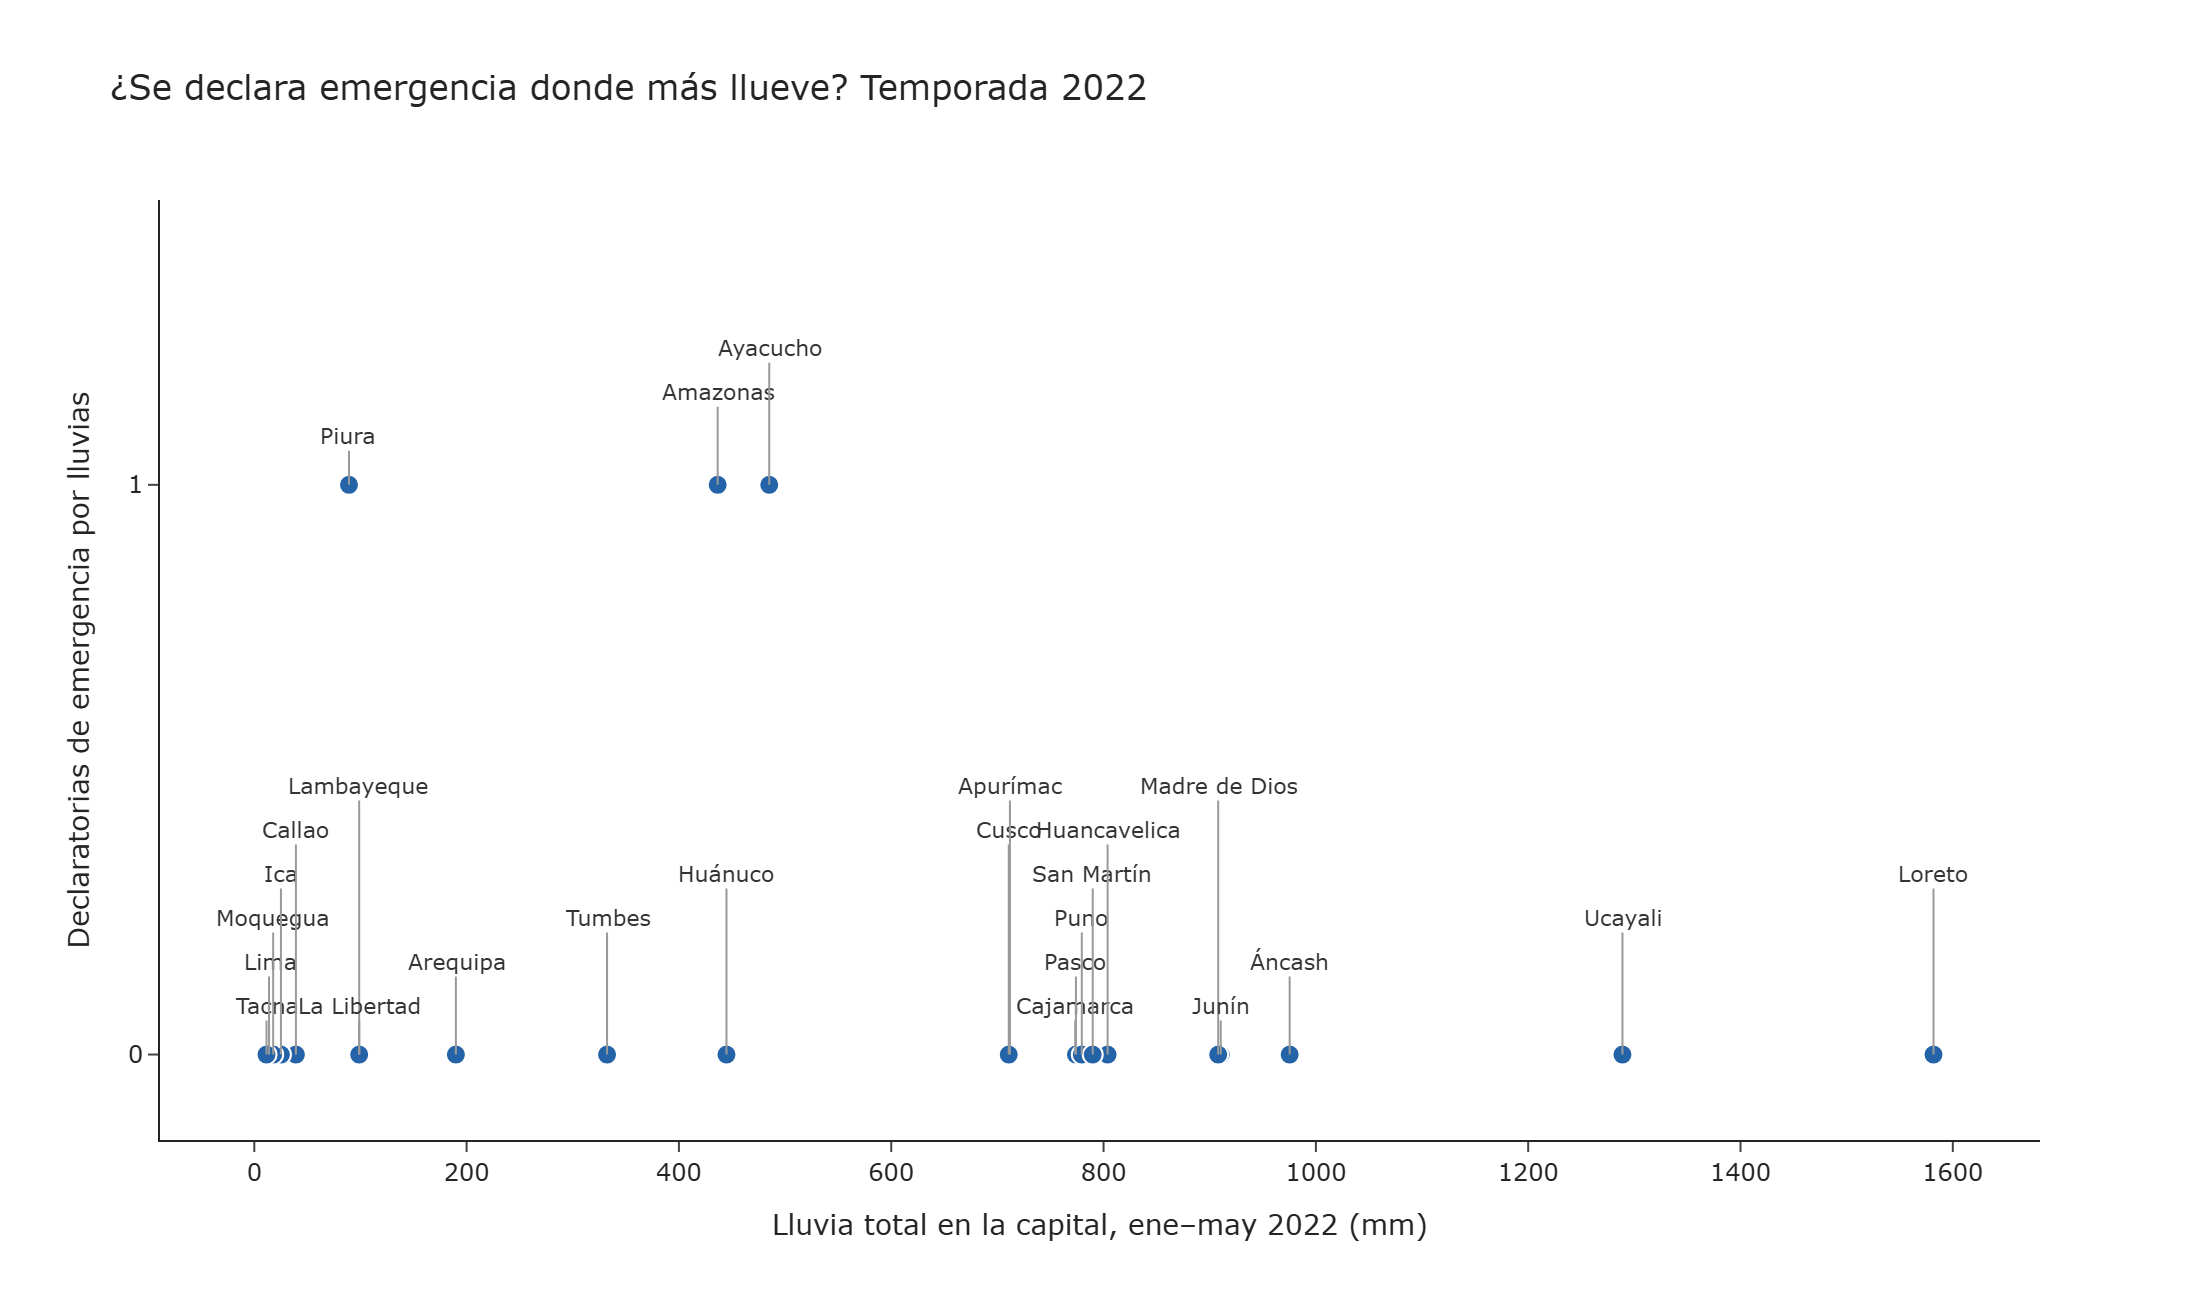

In [11]:
COLOR = "#2563a8"

fig1 = px.scatter(
    tabla_final, x="lluvia_total_mm", y="declaratorias", hover_name="departamento",
    hover_data={"capital": True, "dias_lluvia_fuerte": True, "prorrogas": True},
    labels={"lluvia_total_mm": "Lluvia total en la capital, ene–may 2022 (mm)",
            "declaratorias": "Declaratorias de emergencia por lluvias"},
    title="¿Se declara emergencia donde más llueve? Temporada 2022",
)
fig1.update_traces(marker=dict(size=10, color=COLOR, line=dict(width=1, color="white")))

# Nombre de cada departamento. Muchos puntos están casi en el mismo lugar (costa ~0-40 mm,
# sierra ~770-810 mm), así que escalonamos la altura de las etiquetas y las unimos al punto con una flecha.
for nivel, grupo in tabla_final.sort_values("lluvia_total_mm").groupby("declaratorias"):
    for i, (_, fila) in enumerate(grupo.iterrows()):
        fig1.add_annotation(x=fila["lluvia_total_mm"], y=fila["declaratorias"], text=fila["departamento"],
                            showarrow=True, arrowhead=0, arrowwidth=1, arrowcolor="#999",
                            ax=0, ay=-25 - 22 * (i % 6), font=dict(size=11, color="#333"))

fig1.update_layout(template="simple_white", height=650, width=1100,
                   yaxis=dict(dtick=1, range=[-0.15, tabla_final["declaratorias"].max() + 0.5]))
fig1.show()
fig1.write_image("graficos/dispersion_lluvia_declaratorias.png", scale=2)
display(Image("graficos/dispersion_lluvia_declaratorias.png", width=900))

# Para el gráfico de barras ordenamos por declaratorias y, si hay empate, por lluvia. Como en 2022 **solo 3 departamentos tienen alguna declaratoria**, los otros 7 del "top 10" tienen 0. Los mostramos igual, porque eso también es un resultado: los departamentos más lluviosos no recibieron declaratorias.

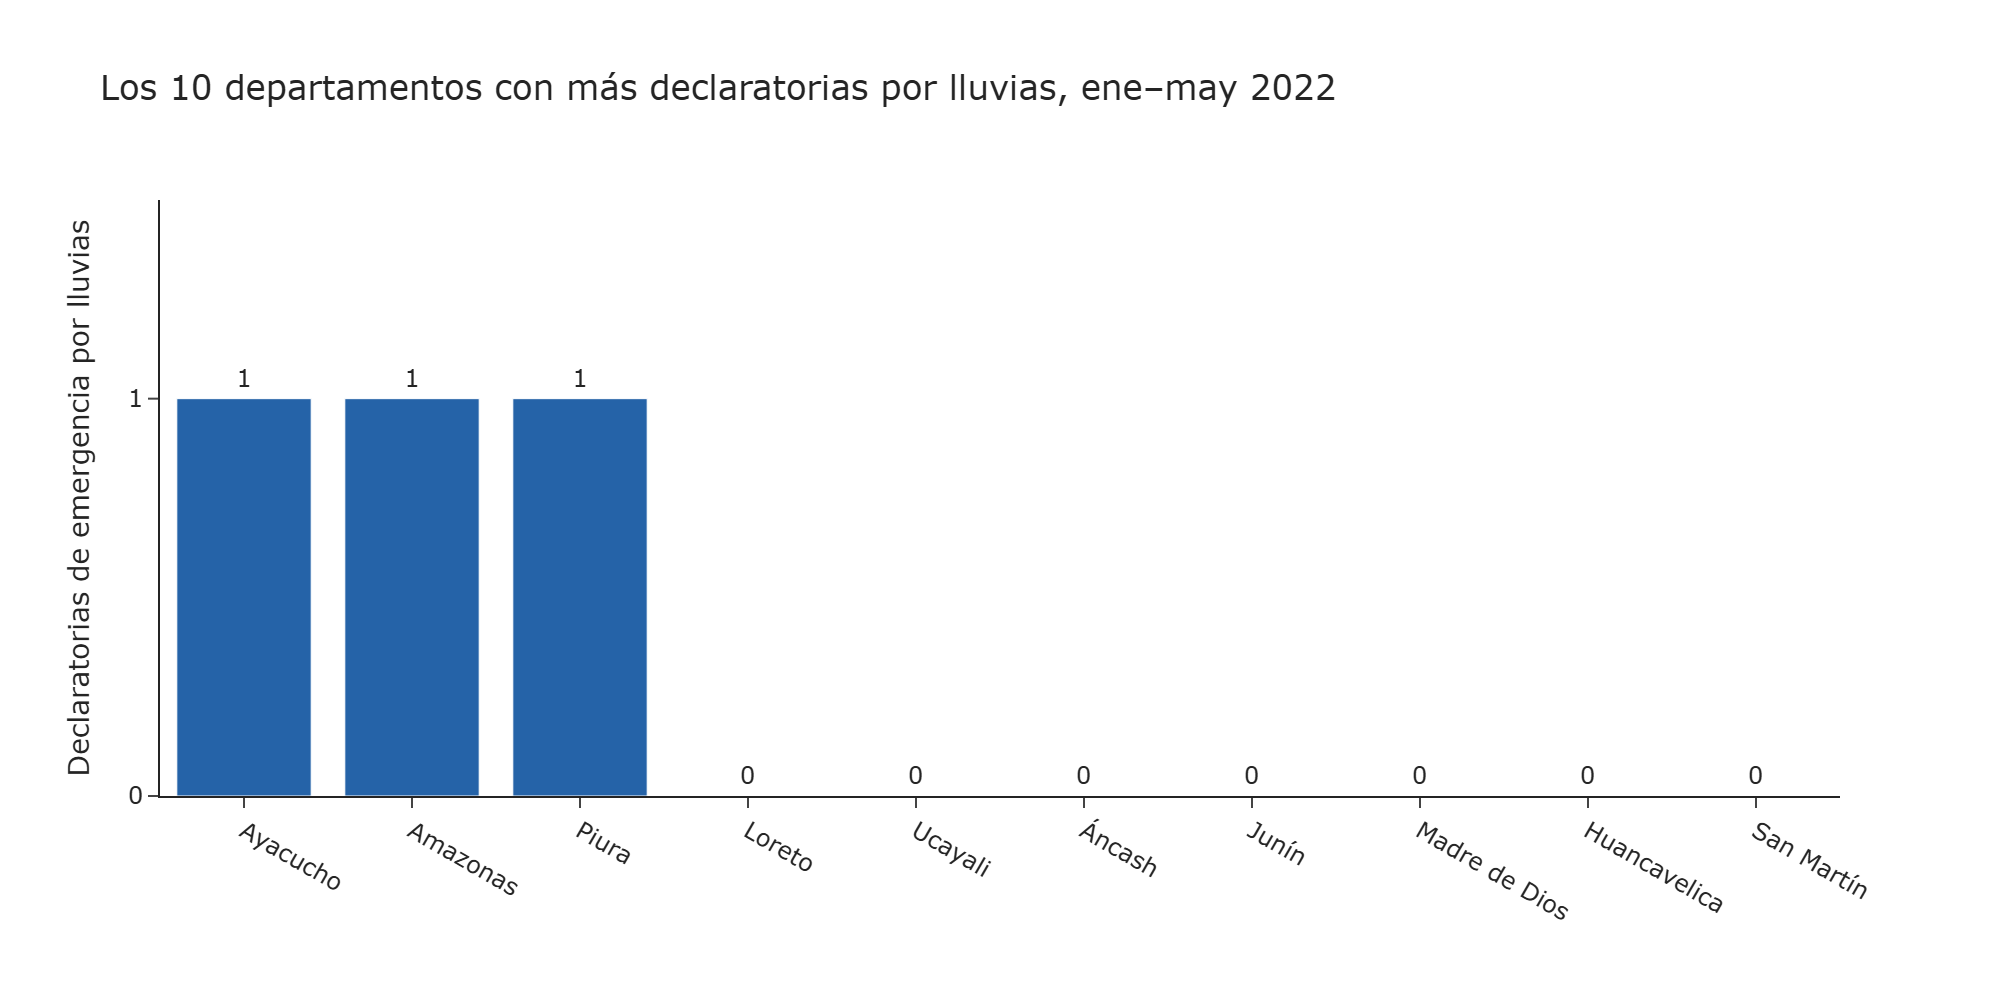

In [12]:
top10 = (tabla_final.sort_values(["declaratorias", "lluvia_total_mm"], ascending=[False, False])
         .head(10))

fig2 = px.bar(
    top10, x="departamento", y="declaratorias", text="declaratorias",
    hover_data={"lluvia_total_mm": True, "prorrogas": True},
    labels={"departamento": "", "declaratorias": "Declaratorias de emergencia por lluvias"},
    title="Los 10 departamentos con más declaratorias por lluvias, ene–may 2022",
)
fig2.update_traces(marker_color=COLOR, textposition="outside")
fig2.update_layout(template="simple_white", height=500, width=1000,
                   yaxis=dict(dtick=1, range=[0, top10["declaratorias"].max() + 0.5]))
fig2.show()
fig2.write_image("graficos/top10_declaratorias.png", scale=2)
display(Image("graficos/top10_declaratorias.png", width=900))

# ## Paso 9: análisis
#
# Calculamos algunos números de apoyo para las respuestas.

In [13]:
tabla_final["ranking_lluvia"] = tabla_final["lluvia_total_mm"].rank(ascending=False, method="min").astype(int)

print("Top 3 por declaratorias:")
print(tabla_final.sort_values(["declaratorias", "lluvia_total_mm"], ascending=False)
      [["departamento", "declaratorias", "lluvia_total_mm", "ranking_lluvia"]].head(3).to_string(index=False))

print("\nTop 3 por lluvia:")
print(tabla_final.sort_values("lluvia_total_mm", ascending=False)
      [["departamento", "lluvia_total_mm", "dias_lluvia_fuerte", "declaratorias"]].head(3).to_string(index=False))

print("\nLluvia promedio según si tuvo declaratoria:")
print(tabla_final.groupby(tabla_final["declaratorias"] > 0)[["lluvia_total_mm", "dias_lluvia_fuerte"]]
      .mean().round(1).rename(index={True: "con declaratoria", False: "sin declaratoria"}))

Top 3 por declaratorias:
departamento  declaratorias  lluvia_total_mm  ranking_lluvia
    Ayacucho              1            485.1              13
    Amazonas              1            436.5              15
       Piura              1             89.2              20

Top 3 por lluvia:
departamento  lluvia_total_mm  dias_lluvia_fuerte  declaratorias
      Loreto           1581.8                  25              0
     Ucayali           1288.8                  20              0
      Áncash            975.3                   7              0

Lluvia promedio según si tuvo declaratoria:
                  lluvia_total_mm  dias_lluvia_fuerte
declaratorias                                        
sin declaratoria            558.2                 4.0
con declaratoria            336.9                 0.3


In [14]:
decretos_lluvias = pd.read_csv("datos/decretos_lluvias.csv")
declaratorias = decretos_lluvias[decretos_lluvias["tipo"] == "declara"]
print("Número de declaratorias:", len(declaratorias))
print((declaratorias["motivo"].value_counts(normalize=True) * 100).round(1).astype(str) + " %")
declaratorias[["numero", "fecha", "motivo", "titulo"]]

Número de declaratorias: 1
motivo
impacto de daños    100.0 %
Name: proportion, dtype: str


,numero,fecha,motivo,titulo
0,Decreto Supremo N.° 032-2022-PCM,2022-04-01,impacto de daños,Decreto Supremo que declara el Estado de Emerg...


# ### 1. ¿Cuáles fueron los 3 departamentos con más declaratorias? ¿Coinciden con los 3 donde más llovió?
#
# Los 3 departamentos con declaratorias son **Amazonas, Ayacucho y Piura**, con **1 cada uno**. Están empatados porque los tres aparecen en el mismo y único decreto de lluvias de la temporada (DS 032-2022-PCM, del 1 de abril de 2022).
#
# **No coinciden** con los 3 donde más llovió: **Loreto** (1 581.8 mm), **Ucayali** (1 288.8 mm) y **Áncash** (975.3 mm). Ninguno de ellos tuvo declaratoria. Según la lluvia en su capital, Ayacucho ocupa el puesto 13 de 25, Amazonas el 15 y Piura el 20. Es decir, Piura está entre los departamentos **más secos** del grupo.
#
# ### 2. ¿Hay departamentos con mucha lluvia y pocas o ninguna declaratoria, o al revés?
#
# Sí, en los dos sentidos:
# - **Mucha lluvia y ninguna declaratoria:** Loreto (1 581.8 mm y 25 días de lluvia fuerte), Ucayali (1 288.8 mm y 20 días) y Madre de Dios (908.0 mm y 13 días). También Áncash y Junín. En promedio, los 22 departamentos sin declaratoria tuvieron **más** lluvia (558.2 mm y 4.0 días de lluvia fuerte) que los 3 con declaratoria (336.9 mm y 0.3 días).
# - **Poca lluvia y con declaratoria:** Piura, con solo 89.2 mm y 0 días de lluvia fuerte en su capital.
#
# Razones posibles:
# 1. **Medimos la lluvia en un solo punto (la capital), no donde ocurrió el daño.** El decreto habla de *"algunos distritos de varias provincias"*. En Piura, la ciudad está en la costa desértica, pero el departamento también tiene provincias de sierra (como Huancabamba y Ayabaca), donde llueve mucho más. La emergencia pudo deberse a lluvias en esas zonas, que nuestro dato no capta.
# 2. **Lo que causa la emergencia es el daño, no la cantidad de lluvia.** El daño depende de la **vulnerabilidad**: pendientes, quebradas que se activan con huaicos, viviendas precarias, carreteras expuestas. En la selva llueve mucho todos los años y la población y la infraestructura están más adaptadas a eso. En cambio, un episodio corto e intenso en una zona de quebradas puede causar mucho daño aunque el total de la temporada sea bajo.
# 3. **La declaratoria es un proceso administrativo.** El gobierno regional la pide con informes técnicos e INDECI la evalúa. Un departamento puede no pedirla si puede responder con sus propios recursos, o si no tiene capacidad técnica para armar el expediente.
# 4. **Puede faltar información:** el buscador de gob.pe solo devolvió 1 decreto de lluvias de la PCM para 2022 (ver Parte 1). Si faltan decretos, algunos departamentos lluviosos aparecerían con 0 sin que eso sea real.
#
# ### 3. ¿Qué porcentaje de las declaratorias fue por peligro inminente y qué porcentaje por impacto de daños?
#
# De las declaratorias por lluvias de 2022, el **100 %** fue por **impacto de daños** y el **0 %** por **peligro inminente**. Hubo una sola declaratoria y fue por impacto de daños.
#
# Esto sugiere una gestión del riesgo **reactiva**: el Estado declaró la emergencia **después** de que las lluvias causaron daños, no antes para prevenirlos. La declaratoria por peligro inminente sirve para actuar **antes** del desastre (limpiar cauces, reforzar defensas ribereñas, reubicar familias), y es lo que busca el enfoque preventivo del Sistema Nacional de Gestión del Riesgo de Desastres. Con un solo decreto no se puede generalizar, pero en lo que encontramos no hay ninguna acción preventiva.
#
# ### 4. Limitaciones del análisis
#
# 1. **Muy pocos decretos.** Solo encontramos 1 decreto de lluvias para toda la temporada. Con 3 departamentos con valor distinto de 0 no se puede medir una relación estadística. Además, el buscador de gob.pe podría no tener todos los decretos publicados en *El Peruano*.
# 2. **Solo usamos el título.** Clasificamos los decretos con palabras del título. Varias prórrogas no dicen el motivo en el título, y sus PDF son imágenes escaneadas sin texto. Si alguna era por lluvias, no la contamos.
# 3. **Un solo punto por departamento.** La lluvia de la capital no representa a todo el departamento, sobre todo en los que tienen costa, sierra y selva (Piura, Lima, Áncash, Cusco, Junín). En Lima, además, tuvimos que elegir entre Huacho y Lima ciudad.
# 4. **Contamos decretos por departamento, no distritos ni personas afectadas.** Un decreto que cubre 2 distritos pesa lo mismo que uno que cubre 50.
# 5. **Los datos de lluvia son estimaciones.** Open-Meteo usa modelos de reanálisis con celdas de varios kilómetros, no pluviómetros en la ciudad. En zonas de montaña puede haber diferencias con lo medido por el SENAMHI.
# 6. **La lluvia total no mide la intensidad.** Una emergencia suele venir de pocos días de lluvia extrema. El total de 5 meses puede esconder eso; `dias_lluvia_fuerte` ayuda, pero el umbral de 20 mm es el mismo para la selva y para la costa.
#
# ### 5. Conclusión
#
# En la temporada 2022, **la respuesta es no: el Estado no declaró emergencia donde más llovió.** El único decreto de lluvias de la PCM que encontramos (DS 032-2022-PCM) cubrió Amazonas, Ayacucho y Piura, que están en los puestos 15, 13 y 20 de 25 en lluvia total. Mientras tanto, los departamentos más lluviosos (Loreto, Ucayali y Áncash) no tuvieron ninguna declaratoria. La declaratoria fue por **impacto de daños**, lo que indica que la emergencia responde al daño ocurrido y a la vulnerabilidad de cada zona más que a cuánta lluvia cae en total. Sin embargo, la evidencia es **muy débil**: hay un solo decreto, la lluvia se midió solo en las capitales y el buscador de gob.pe podría estar incompleto. Para responder mejor habría que medir la lluvia en los distritos declarados y comparar varias temporadas.